In [115]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.preprocessing import OneHotEncoder

In [116]:
df = pd.read_csv('DataSet_Ads_Clean.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8630 entries, 0 to 8629
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       8630 non-null   int64  
 1   Age              8630 non-null   int64  
 2   Gender           8630 non-null   object 
 3   Income           8630 non-null   float64
 4   Location         8630 non-null   object 
 5   Ad Type          8630 non-null   object 
 6   Ad Topic         8630 non-null   object 
 7   Ad Placement     8630 non-null   object 
 8   Clicks           8630 non-null   int64  
 9   Click Time       8630 non-null   object 
 10  Conversion Rate  8630 non-null   float64
 11  CTR              8630 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 809.2+ KB


In [117]:
df.head()

,Unnamed: 0,Age,Gender,Income,Location,Ad Type,Ad Topic,Ad Placement,Clicks,Click Time,Conversion Rate,CTR
0,0,61,Male,35717.43,Urban,Banner,Travel,Social Media,3,2024-01-18 20:45:56.898459,0.0981,0.0737
1,1,41,Male,47453.25,Rural,Video,Travel,Search Engine,5,2023-04-24 20:45:56.898459,0.0937,0.0592
2,2,49,Female,68126.35,Rural,Text,Food,Social Media,4,2024-02-24 20:45:56.898459,0.1912,0.0563
3,3,68,Female,64585.73,Suburban,Text,Health,Website,6,2023-12-13 20:45:56.898459,0.1122,0.0232
4,4,63,Male,21109.40,Urban,Native,Fashion,Search Engine,5,2023-07-02 20:45:56.898459,0.1426,0.0539


In [118]:
# select categorical columns
categorical_cols = ["Gender", "Location", "Ad Type", "Ad Topic", "Ad Placement"]

# apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df_encoded.head())

   Unnamed: 0  Age    Income  Clicks                  Click Time  \
0           0   61  35717.43       3  2024-01-18 20:45:56.898459   
1           1   41  47453.25       5  2023-04-24 20:45:56.898459   
2           2   49  68126.35       4  2024-02-24 20:45:56.898459   
3           3   68  64585.73       6  2023-12-13 20:45:56.898459   
4           4   63  21109.40       5  2023-07-02 20:45:56.898459   

   Conversion Rate     CTR  Gender_Male  Gender_Other  Location_Suburban  ...  \
0           0.0981  0.0737         True         False              False  ...   
1           0.0937  0.0592         True         False              False  ...   
2           0.1912  0.0563        False         False              False  ...   
3           0.1122  0.0232        False         False               True  ...   
4           0.1426  0.0539         True         False              False  ...   

   Ad Type_Native  Ad Type_Text  Ad Type_Video  Ad Topic_Finance  \
0           False         False     

In [119]:
df_encoded = df_encoded.set_index('Age')
df = df.set_index('Age')
df.head()

,Unnamed: 0,Gender,Income,Location,Ad Type,Ad Topic,Ad Placement,Clicks,Click Time,Conversion Rate,CTR
Age,,,,,,,,,,,
61,0,Male,35717.43,Urban,Banner,Travel,Social Media,3,2024-01-18 20:45:56.898459,0.0981,0.0737
41,1,Male,47453.25,Rural,Video,Travel,Search Engine,5,2023-04-24 20:45:56.898459,0.0937,0.0592
49,2,Female,68126.35,Rural,Text,Food,Social Media,4,2024-02-24 20:45:56.898459,0.1912,0.0563
68,3,Female,64585.73,Suburban,Text,Health,Website,6,2023-12-13 20:45:56.898459,0.1122,0.0232
63,4,Male,21109.40,Urban,Native,Fashion,Search Engine,5,2023-07-02 20:45:56.898459,0.1426,0.0539


In [120]:
df_encoded.head()

,Unnamed: 0,Income,Clicks,Click Time,Conversion Rate,CTR,Gender_Male,Gender_Other,Location_Suburban,Location_Urban,Ad Type_Native,Ad Type_Text,Ad Type_Video,Ad Topic_Finance,Ad Topic_Food,Ad Topic_Health,Ad Topic_Technology,Ad Topic_Travel,Ad Placement_Social Media,Ad Placement_Website
Age,,,,,,,,,,,,,,,,,,,,
61,0,35717.43,3,2024-01-18 20:45:56.898459,0.0981,0.0737,True,False,False,True,False,False,False,False,False,False,False,True,True,False
41,1,47453.25,5,2023-04-24 20:45:56.898459,0.0937,0.0592,True,False,False,False,False,False,True,False,False,False,False,True,False,False
49,2,68126.35,4,2024-02-24 20:45:56.898459,0.1912,0.0563,False,False,False,False,False,True,False,False,True,False,False,False,True,False
68,3,64585.73,6,2023-12-13 20:45:56.898459,0.1122,0.0232,False,False,True,False,False,True,False,False,False,True,False,False,False,True
63,4,21109.40,5,2023-07-02 20:45:56.898459,0.1426,0.0539,True,False,False,True,True,False,False,False,False,False,False,False,False,False


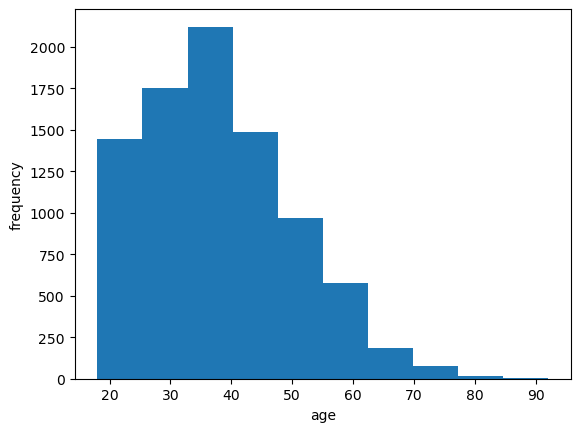

In [121]:
plt.hist(df.index)
plt.xlabel('age')
plt.ylabel('frequency')
plt.show()

In [122]:
#create binary column for users over 50
#find trends in users over 50
df['Over_50'] = df.index > 50
df_encoded['Over_50'] = df_encoded.index > 50
df['Over_50'].describe()

count      8630
unique        2
top       False
freq       7278
Name: Over_50, dtype: object

In [123]:
print(df.groupby('Over_50')['Clicks'].median(), df.groupby('Over_50')['CTR'].median(), df.groupby('Over_50')['Conversion Rate'].median())

Over_50
False    5.0
True     5.0
Name: Clicks, dtype: float64 Over_50
False    0.0506
True     0.0497
Name: CTR, dtype: float64 Over_50
False    0.181
True     0.178
Name: Conversion Rate, dtype: float64


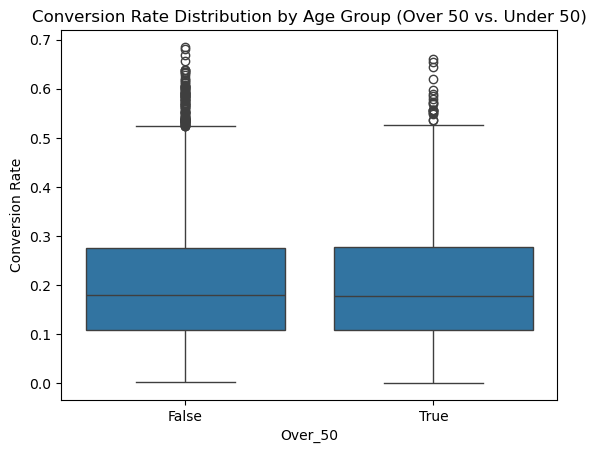

In [124]:
sns.boxplot(x=df['Over_50'], y=df['Conversion Rate'])
plt.title("Conversion Rate Distribution by Age Group (Over 50 vs. Under 50)")
plt.show()

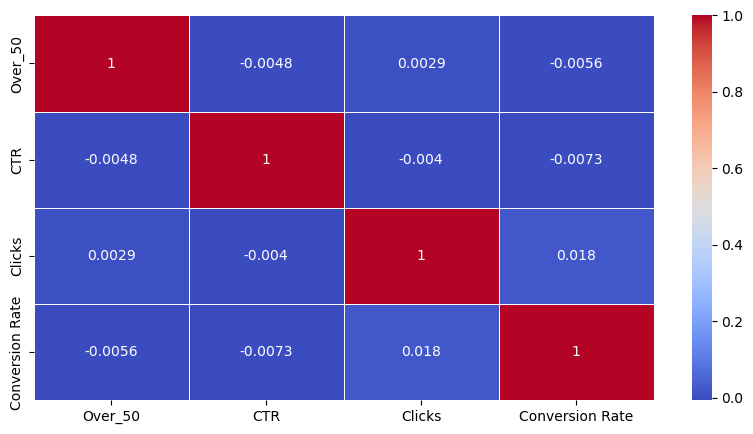

In [125]:
plt.figure(figsize=(10,5))
sns.heatmap(df[["Over_50", "CTR", "Clicks", "Conversion Rate"]].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

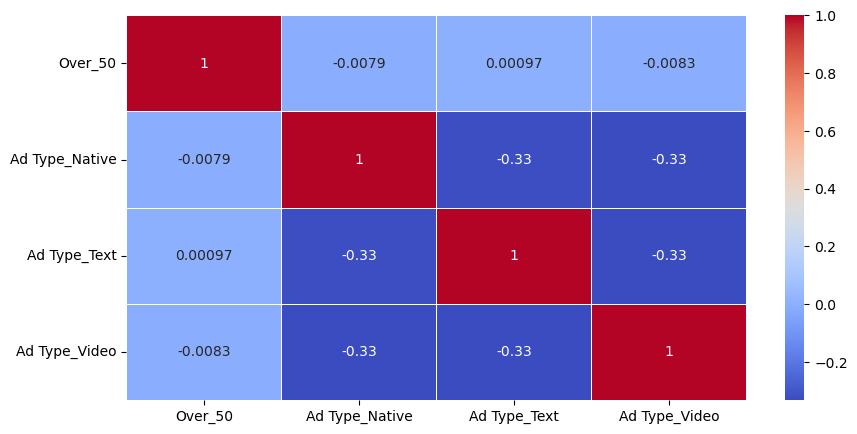

In [126]:
plt.figure(figsize=(10,5))
sns.heatmap(df_encoded[["Over_50", "Ad Type_Native","Ad Type_Text", "Ad Type_Video"]].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

In [127]:
#Over_50 has the highest correlation with Text

In [128]:
df_encoded_over_50 = df_encoded[df_encoded.index >= 50]
df_over_50 = df[df.index >= 50]

In [129]:
print(df_over_50.groupby("Ad Type")["Conversion Rate"].mean(),
df_over_50.groupby("Ad Type")["CTR"].mean(),
df_over_50.groupby("Ad Type")["Clicks"].mean())

Ad Type
Banner    0.199172
Native    0.191283
Text      0.202542
Video     0.205212
Name: Conversion Rate, dtype: float64 Ad Type
Banner    0.051529
Native    0.049816
Text      0.050428
Video     0.051038
Name: CTR, dtype: float64 Ad Type
Banner    4.997494
Native    5.027778
Text      5.000000
Video     5.224377
Name: Clicks, dtype: float64


<Axes: xlabel='Ad Type', ylabel='Clicks'>

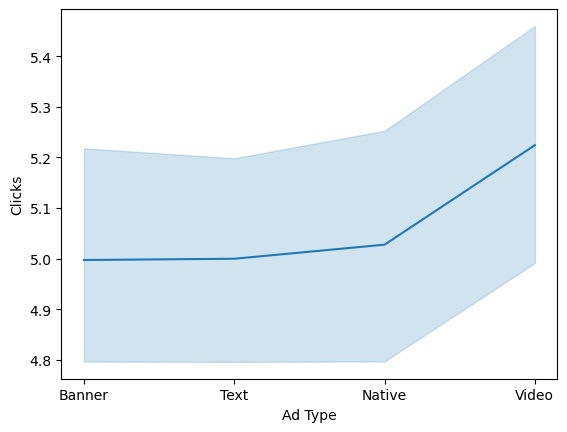

In [130]:
sns.lineplot(data=df_over_50, x="Ad Type", y="Clicks")

<Axes: xlabel='Ad Type', ylabel='Conversion Rate'>

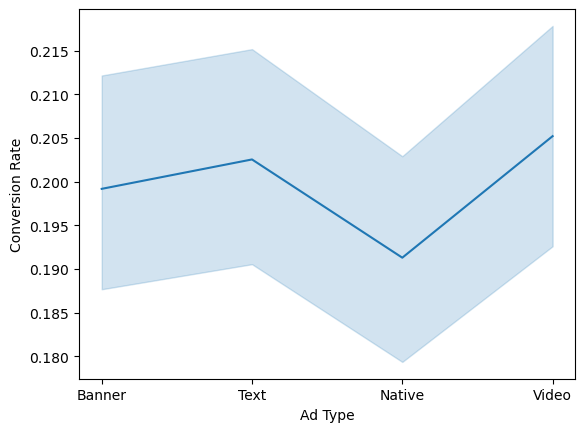

In [131]:
sns.lineplot(data=df_over_50, x="Ad Type", y="Conversion Rate")

<Axes: xlabel='Ad Type', ylabel='CTR'>

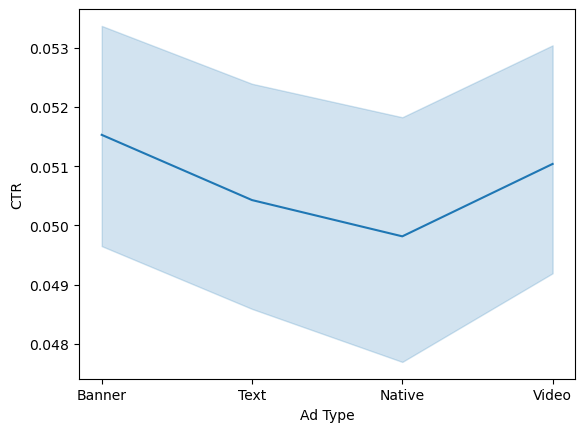

In [132]:
sns.lineplot(data=df_over_50, x="Ad Type", y="CTR")

In [133]:
#Video is the most consistently high ad type
#Hypothesis: video ads are more effective in targeting those 50+

                 Unnamed: 0    Income    Clicks  Conversion Rate       CTR
Unnamed: 0         1.000000 -0.002856 -0.033764         0.046649 -0.011165
Income            -0.002856  1.000000  0.031286         0.025004  0.006451
Clicks            -0.033764  0.031286  1.000000        -0.000441  0.006560
Conversion Rate    0.046649  0.025004 -0.000441         1.000000 -0.056288
CTR               -0.011165  0.006451  0.006560        -0.056288  1.000000


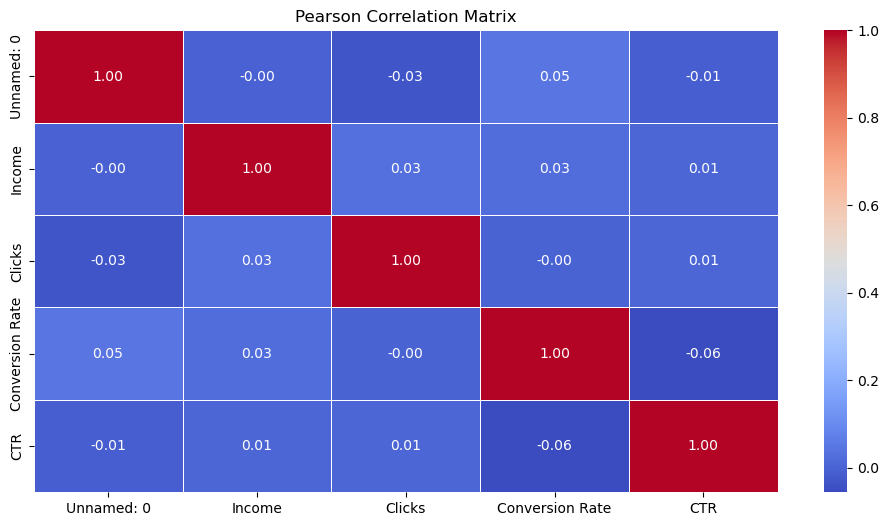

In [134]:
numeric_df = df_over_50.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr(method='pearson')

print(correlation_matrix)

plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Matrix")
plt.show()

<Axes: xlabel='Ad Placement', ylabel='Ad Type'>

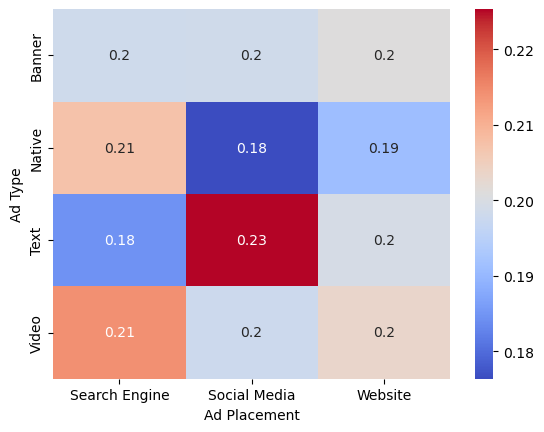

In [135]:
pivot = df_over_50.pivot_table(values="Conversion Rate", index="Ad Type", columns="Ad Placement")
sns.heatmap(pivot, annot=True, cmap="coolwarm")

In [136]:
#Video & Search Engine and Text & Social Media have the highest correlations. 

In [137]:
print(df_over_50.shape, df_over_50.shape)

(1493, 12) (1493, 12)


In [138]:
df = df_over_50.merge(df_encoded_over_50, how='inner', on='Income')
df.shape
df.head()

,Unnamed: 0_x,Gender,Income,Location,Ad Type,Ad Topic,Ad Placement,Clicks_x,Click Time_x,Conversion Rate_x,...,Ad Type_Text,Ad Type_Video,Ad Topic_Finance,Ad Topic_Food,Ad Topic_Health,Ad Topic_Technology,Ad Topic_Travel,Ad Placement_Social Media,Ad Placement_Website,Over_50_y
0,0,Male,35717.43,Urban,Banner,Travel,Social Media,3,2024-01-18 20:45:56.898459,0.0981,...,False,False,False,False,False,False,True,True,False,True
1,3,Female,64585.73,Suburban,Text,Health,Website,6,2023-12-13 20:45:56.898459,0.1122,...,True,False,False,False,True,False,False,False,True,True
2,4,Male,21109.40,Urban,Native,Fashion,Search Engine,5,2023-07-02 20:45:56.898459,0.1426,...,False,False,False,False,False,False,False,False,False,True
3,11,Male,84335.16,Rural,Video,Food,Search Engine,8,2024-01-03 20:45:56.898459,0.1640,...,False,True,False,True,False,False,False,False,False,True
4,16,Female,29682.04,Rural,Video,Technology,Search Engine,10,2023-12-07 20:45:56.898459,0.1190,...,False,True,False,False,False,True,False,False,False,True


In [139]:
df = df[['Income', 'Location', 'Ad Type', 'Ad Placement', 'Clicks_x', 'Conversion Rate_x', 'CTR_x', 'Ad Type', 'Ad Type_Text', 'Ad Type_Video']]
df = df.loc[:, ~df.columns.duplicated()]
df = df.rename(columns={'Clicks_x': 'Clicks', 'Conversion Rate_x': 'Conversion Rate', 'CTR_x': 'CTR'})
df.head()

,Income,Location,Ad Type,Ad Placement,Clicks,Conversion Rate,CTR,Ad Type_Text,Ad Type_Video
0,35717.43,Urban,Banner,Social Media,3,0.0981,0.0737,False,False
1,64585.73,Suburban,Text,Website,6,0.1122,0.0232,True,False
2,21109.40,Urban,Native,Search Engine,5,0.1426,0.0539,False,False
3,84335.16,Rural,Video,Search Engine,8,0.1640,0.0777,False,True
4,29682.04,Rural,Video,Search Engine,10,0.1190,0.0538,False,True


In [140]:
df.to_csv('Dataset_Ads_EDA.csv')